<a href="https://colab.research.google.com/github/marlon-2006/01_IntroPython_Marlon-Shiguango/blob/main/Exam1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
KPIs DEL CALL CENTER
Total de llamadas: 5000
% Llamadas contestadas: 81.08%
% Llamadas resueltas: 72.92%
Tiempo promedio de respuesta: 67.52 segundos
Satisfacción promedio: 3.40/5

 SATISFACCIÓN POR AGENTE
Agent
Martha     3.470817
Dan        3.447419
Diane      3.405190
Greg       3.404382
Stewart    3.400419
Jim        3.393657
Becky      3.371373
Joe        3.330579
Name: Satisfaction rating, dtype: float64

 TIEMPO PROMEDIO DE RESPUESTA POR AGENTE
Agent
Becky      65.330754
Stewart    66.184486
Diane      66.267465
Jim        66.343284
Dan        67.282983
Greg       68.444223
Martha     69.488327
Joe        70.987603
Name: Speed of answer in seconds, dtype: float64

 LLAMADAS POR AGENTE
Agent
Jim        666
Martha     638
Dan        633
Diane      633
Becky      631
Greg       624
Joe        593
Stewart    582
Name: Call Id, dtype: int64

 LLAMADAS POR T

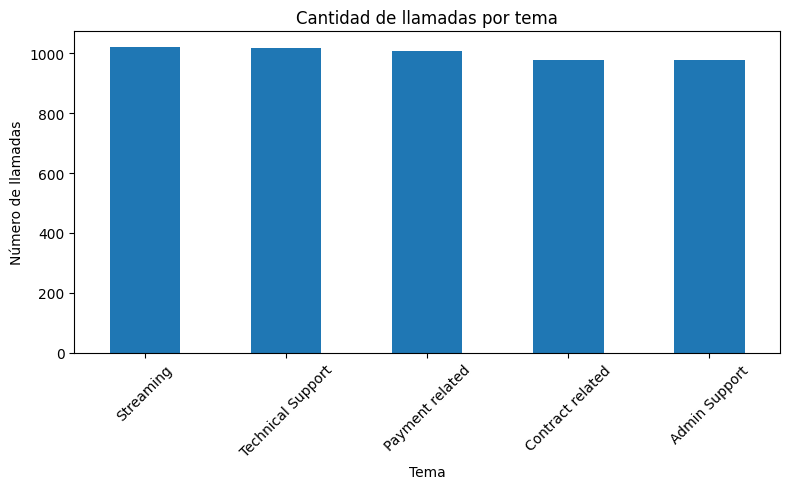

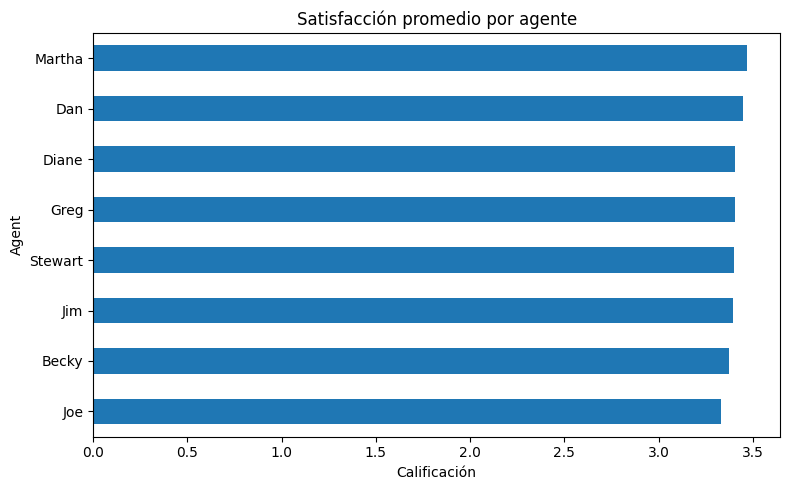

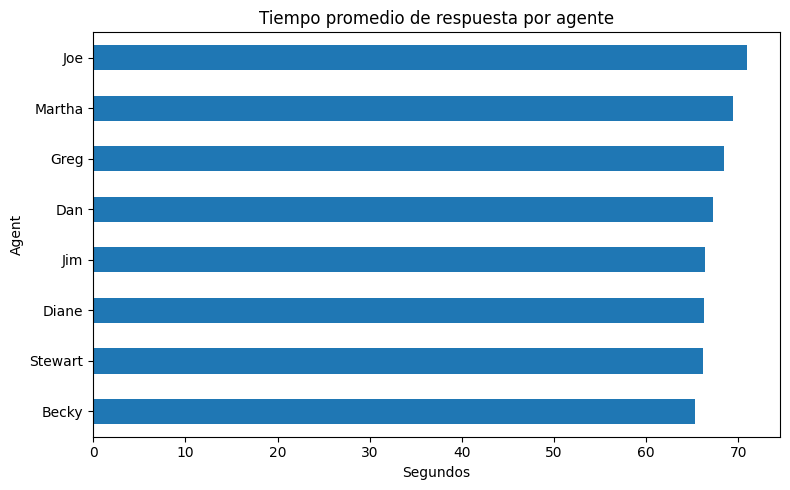

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('01 Call-Center-Dataset.xlsx')

df['Satisfaction rating'] = pd.to_numeric(
    df['Satisfaction rating'],
    errors='coerce'
)

total_calls = len(df)

answered_rate = (df['Answered (Y/N)'] == 'Y').mean() * 100

resolution_rate = (df['Resolved'] == 'Y').mean() * 100

avg_speed = df['Speed of answer in seconds'].mean()

avg_satisfaction = df['Satisfaction rating'].mean()

print("="*50)
print("KPIs DEL CALL CENTER")
print("="*50)
print(f"Total de llamadas: {total_calls}")
print(f"% Llamadas contestadas: {answered_rate:.2f}%")
print(f"% Llamadas resueltas: {resolution_rate:.2f}%")
print(f"Tiempo promedio de respuesta: {avg_speed:.2f} segundos")
print(f"Satisfacción promedio: {avg_satisfaction:.2f}/5")
print("="*50)

# AGENTE

print("\n SATISFACCIÓN POR AGENTE")
print(
    df.groupby('Agent')['Satisfaction rating']
      .mean()
      .sort_values(ascending=False)
)

print("\n TIEMPO PROMEDIO DE RESPUESTA POR AGENTE")
print(
    df.groupby('Agent')['Speed of answer in seconds']
      .mean()
      .sort_values()
)

print("\n LLAMADAS POR AGENTE")
print(
    df.groupby('Agent')['Call Id']
      .count()
      .sort_values(ascending=False)
)

print("\n LLAMADAS POR TEMA")
print(df['Topic'].value_counts())

print("\n TASA DE RESOLUCIÓN POR TEMA")
print(
    df.groupby('Topic')['Resolved']
      .apply(lambda x: (x == 'Y').mean()*100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

df['Topic'].value_counts().plot(kind='bar')

plt.title('Cantidad de llamadas por tema')
plt.xlabel('Tema')
plt.ylabel('Número de llamadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

df.groupby('Agent')['Satisfaction rating'] \
  .mean() \
  .sort_values() \
  .plot(kind='barh')

plt.title('Satisfacción promedio por agente')
plt.xlabel('Calificación')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))

df.groupby('Agent')['Speed of answer in seconds'] \
  .mean() \
  .sort_values() \
  .plot(kind='barh')

plt.title('Tiempo promedio de respuesta por agente')
plt.xlabel('Segundos')
plt.tight_layout()
plt.show()



